![CCAI 9012 course banner](../../../docs/figs/brand_identity/banner.png)

# Historic-area CLIP: from street images to a map of model scores

Imagine surveying Barcelona street scenes to find places that **look more similar to a historic-building description**. Visiting every point would take time, so this lesson uses street images and CLIP to produce candidate scores for inspection. You will connect each image to its coordinates, compare it with four text prompts, and read the resulting point map.

The default path selects 24 of 582 local images and reads a cached CLIP result table. New Google Street View requests and model inference are explicit options. The OpenStreetMap street layer in the final interactive map still needs a browser connection.

![Data choice and spatial evidence chain](../../../docs/figs/clip_historic_decision_spatial.svg)

A CLIP score expresses similarity **among the prompts supplied here**. It is not a verified historic-status label.



## What you will learn

- explain how a filename joins a street image to latitude, longitude, and camera heading;
- distinguish cached results from a new model or Google API run and read four prompt scores for one image;
- trace the weighted point score back to its prompt scores; and
- explain what the mapped colours can and cannot establish.

## Roadmap

1. **Choose a place and input mode.** The default uses local Barcelona images.
2. **Build a reproducible image sample.** A manifest keeps images and coordinates together.
3. **Compare images with text.** Read four relative CLIP scores for each scene.
4. **Map the score.** Average headings at each coordinate and inspect the result.

## Step 1 — Choose where to look

The box below covers part of Barcelona's Eixample and 22@ area. In the default local mode, it is a spatial reference only. Street-network sampling runs only in the optional API branch.


In [1]:
import ast
import pandas as pd
from IPython.display import display
from tqdm import tqdm

from ccai9012 import svi_utils, viz_utils
from ccai9012.multi_modal_utils import CLIPClassifier
from ccai9012.paths import STARTER_KITS_DIR
from ccai9012.svi_utils import (
    build_svi_image_manifest,
    deterministic_image_sample,
    join_clip_results,
)

RUN_GOOGLE_API = False
RUN_CLIP_MODEL = False  # Set True only when model inference is intended.
SAMPLE_SIZE = 24
SAMPLE_SEED = 42


In [3]:
# Define the bounding box coordinates (Barcelona – Eixample + 22@ Innovation District, Spain)
bbox = (2.1780, 41.3975, 2.2030, 41.4065) # (west, south, east, north)

# Point sampling through OSMnx is also network-backed, so keep it in the opt-in branch.
if RUN_GOOGLE_API:
    m, points = viz_utils.sample_street_points_map(bbox)
    display(m)
else:
    m, points = None, []
    print("Offline sample mode: no route/point API call will be made.")

Offline sample mode: no route/point API call will be made.


## Step 2 — Select a reproducible street-image sample

The local manifest reads each image filename as a coordinate and heading. The same seed selects the same 24 files every time. `RUN_GOOGLE_API` is an opt-in path for new images; the default lesson keeps the tracked local files.


### What the manifest protects

Each later model score must stay attached to the image it came from. The manifest stores `filename`, `image_path`, `latitude`, `longitude`, and `heading`; the library helper checks those links before joining cached scores.


In [5]:
CLIP_DIR = STARTER_KITS_DIR / "3_multimodal_reasoning" / "clip_historic"
IMAGE_DIR = CLIP_DIR / "images"
manifest = build_svi_image_manifest(IMAGE_DIR)
sample_manifest = deterministic_image_sample(manifest, SAMPLE_SIZE, SAMPLE_SEED)
print(f"Manifest: {len(manifest)} tracked images; sample: {len(sample_manifest)} images")
display(sample_manifest[["filename", "latitude", "longitude", "heading"]].head())


Manifest: 582 tracked images; sample: 24 images


,filename,latitude,longitude,heading
0,lat41.397550_lon2.183534_hdg270.jpg,41.397550,2.183534,270
1,lat41.398985_lon2.199498_hdg270.jpg,41.398985,2.199498,270
2,lat41.399113_lon2.183727_hdg90.jpg,41.399113,2.183727,90
3,lat41.399168_lon2.194746_hdg270.jpg,41.399168,2.194746,270
4,lat41.399230_lon2.178870_hdg270.jpg,41.399230,2.178870,270


In [7]:
if RUN_GOOGLE_API:
    downloader = svi_utils.GoogleSVIDownloader(save_dir=str(IMAGE_DIR))
else:
    downloader = None
    print("Sample mode: no Google key requested and no network call will be made.")

Sample mode: no Google key requested and no network call will be made.


In [11]:
if RUN_GOOGLE_API:
    # Camera headings: 0 = North, 90 = East, etc.
    HEADINGS = [90, 270]
    for lat, lon in tqdm(points, desc="Downloading SVI"):
        for heading in HEADINGS:
            filepath = downloader.download_svi(lat, lon, heading=heading)
            if not filepath:
                print(f"Failed: lat={lat:.6f}, lon={lon:.6f}, heading={heading}")
    manifest = build_svi_image_manifest(IMAGE_DIR)
    sample_manifest = deterministic_image_sample(manifest, SAMPLE_SIZE, SAMPLE_SEED)
else:
    print("API mode is disabled. The local manifest remains active.")

API mode is disabled. The local manifest remains active.


## Step 3 — Read the image–text comparison

The four prompts describe **historic**, **modern**, **mixed**, and **open-space** scenes. For each image, CLIP returns a relative score for each prompt. `label_id` identifies the largest of those four scores. The cached table lets you inspect this step without downloading a model.


In [13]:
# Use a cached result table by default; model inference is an explicit opt-in.
CACHED_RESULTS = CLIP_DIR / "inference_results.csv"
if RUN_CLIP_MODEL:
    clip = CLIPClassifier(image_dir=str(IMAGE_DIR))
else:
    clip = None
    print("Offline sample mode: using the tracked CLIP result cache.")

Offline sample mode: using the tracked CLIP result cache.


In [15]:
# Define visual prompt categories (tailored to Barcelona region)
text_prompts = [
    "historic or traditional European buildings made of brick or stone",  # 0 - Historic
    "modern buildings with glass, metal, concrete or painted facade",                            # 1 - Modern
    "a combination of historic and modern buildings in the same scene, showing contrast in architectural styles",             # 2 - Mixed
    "an open public space such as a plaza, park, or square, with no visible buildings in the frame, featuring trees or sky"    # 3 - Open Space
]

if RUN_CLIP_MODEL:
    # Classify only the selected files; this bounds the opt-in model run.
    rows = [clip.classify_image(row["image_path"], text_prompts) for _, row in sample_manifest.iterrows()]
    df_results = pd.DataFrame([row for row in rows if row is not None])
    df_results = join_clip_results(df_results, sample_manifest)
else:
    cached = pd.read_csv(CACHED_RESULTS)
    cached = cached[cached["filename"].isin(sample_manifest["filename"])].copy()
    df_results = join_clip_results(cached, sample_manifest)

# Cached CSV stores the score list as text; parse it once before scoring.
df_results["all_scores"] = df_results["all_scores"].apply(ast.literal_eval)
df_results[["filename", "latitude", "longitude", "heading", "label_id"]].head()

,filename,latitude,longitude,heading,label_id
0,lat41.402070_lon2.179724_hdg90.jpg,41.402070,2.179724,90,0
1,lat41.404395_lon2.178879_hdg90.jpg,41.404395,2.178879,90,0
2,lat41.404986_lon2.194211_hdg90.jpg,41.404986,2.194211,90,0
3,lat41.399113_lon2.183727_hdg90.jpg,41.399113,2.183727,90,0
4,lat41.403272_lon2.193856_hdg270.jpg,41.403272,2.193856,270,1


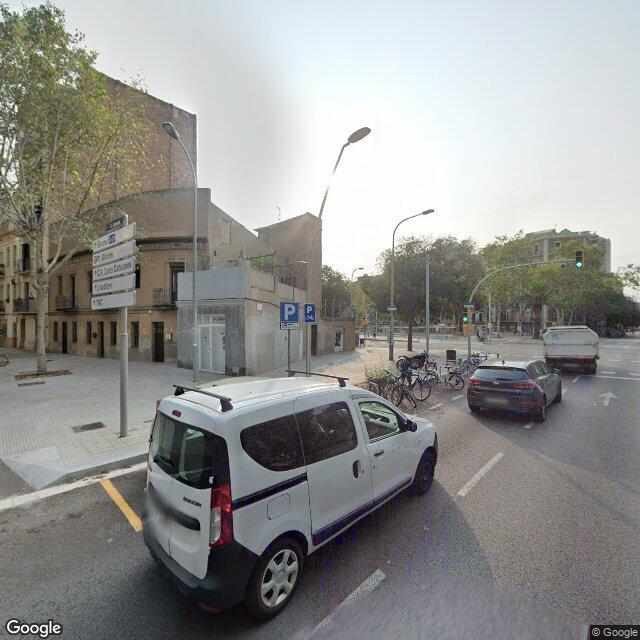

lat41.402070_lon2.179724_hdg90.jpg: historic or traditional European buildings made of brick or stone (score=0.88)


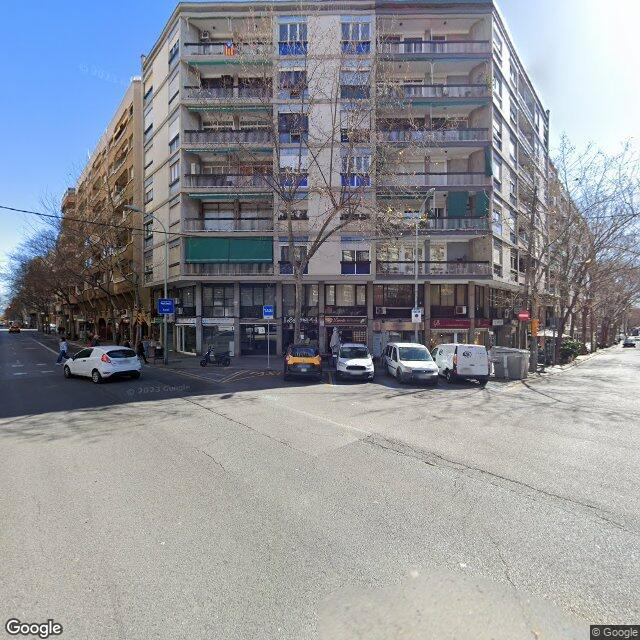

lat41.404395_lon2.178879_hdg90.jpg: historic or traditional European buildings made of brick or stone (score=0.68)


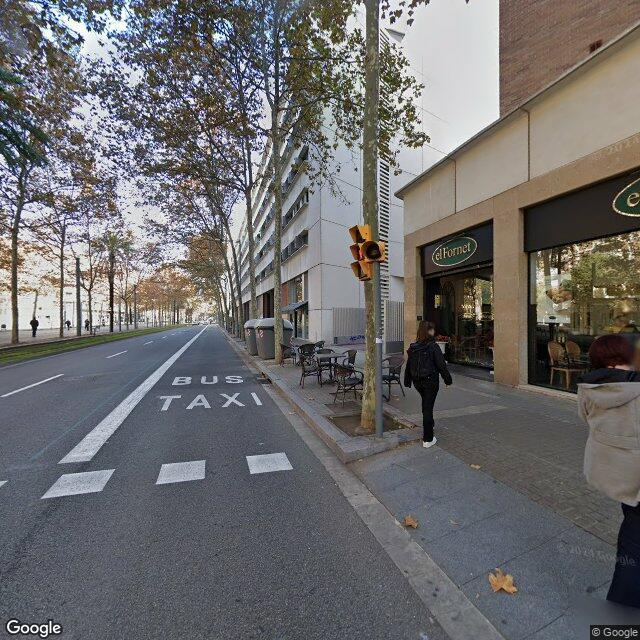

lat41.404986_lon2.194211_hdg90.jpg: historic or traditional European buildings made of brick or stone (score=0.47)


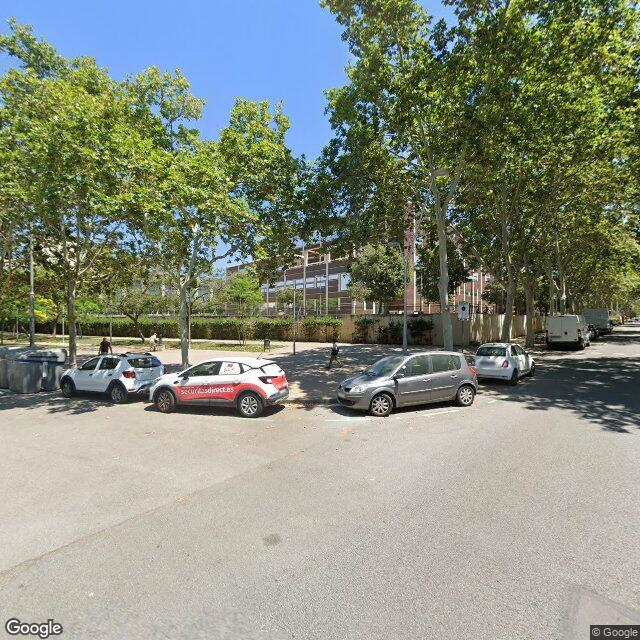

lat41.399113_lon2.183727_hdg90.jpg: historic or traditional European buildings made of brick or stone (score=0.73)


In [17]:
# Show a reproducible sample. The image path comes from the manifest, not parsing.
from PIL import Image
for index in range(min(4, len(df_results))):
    row = df_results.iloc[index]
    display(Image.open(row["image_path"]))
    print(f"{row['filename']}: {row['label_text']} (score={row['confidence']:.2f})")

### Pause: read one scene before the map

Look at a displayed image and its `label_text` together. Does the text describe the visible scene? `confidence` is the largest score after comparing **these four descriptions**; it is not a calibrated probability that a building is historically designated. A different prompt set can change the ranking.


In [19]:
prompt_names = ["Historic", "Modern", "Mixed", "Open space"]
example = df_results.iloc[0]
score_table = pd.DataFrame({
    "prompt": prompt_names,
    "relative_score": example["all_scores"],
    "index_weight": [3, 2, 1, 0],
})
print(f"Image: {example['filename']}")
display(score_table)


Image: lat41.402070_lon2.179724_hdg90.jpg


,prompt,relative_score,index_weight
0,Historic,0.876599,3
1,Modern,0.105414,2
2,Mixed,0.001526,1
3,Open space,0.016461,0


## Step 4 — Map the weighted prompt score

The existing classroom recipe assigns weights **3, 2, 1, 0** to historic, modern, mixed, and open-space prompts, then divides their weighted sum by 6. This is an illustrative index chosen for the lesson. In particular, the modern prompt receives more weight than the mixed prompt, so a high value is **not** a pure measure of historic appearance. The table above makes the assumption visible for critique.

Two camera headings at one coordinate are averaged before mapping. The result is a point score, not a measured heritage designation or a continuous heatmap.


In [21]:
# Coordinates and heading were attached by join_clip_results above.
assert df_results[["latitude", "longitude", "heading"]].notna().all().all()
df_results[["filename", "latitude", "longitude", "heading"]].head()

,filename,latitude,longitude,heading
0,lat41.402070_lon2.179724_hdg90.jpg,41.402070,2.179724,90
1,lat41.404395_lon2.178879_hdg90.jpg,41.404395,2.178879,90
2,lat41.404986_lon2.194211_hdg90.jpg,41.404986,2.194211,90
3,lat41.399113_lon2.183727_hdg90.jpg,41.399113,2.183727,90
4,lat41.403272_lon2.193856_hdg270.jpg,41.403272,2.193856,270


In [23]:
# Teaching weights follow the prompt order: historic, modern, mixed, open space.
weights = {0: 3, 1: 2, 2: 1, 3: 0}

def weighted_score(scores):
    # scores is a list of confidences corresponding to [id0, id1, id2, id3]
    total_weight = 3 + 2 + 1  # sum of weights for id 0,1,2
    score_sum = scores[0]*3 + scores[1]*2 + scores[2]*1
    return score_sum / total_weight

# Calculate weighted score per row
df_results['weighted_score'] = df_results['all_scores'].apply(weighted_score)

# Average the two camera headings at each coordinate before mapping
grouped = df_results.groupby(['latitude', 'longitude'])['weighted_score'].mean().reset_index()
grouped = grouped.rename(columns={
    "latitude":"latitude",
    "longitude":"longitude"
})
grouped

,latitude,longitude,weighted_score
0,41.397550,2.183534,0.403100
1,41.398985,2.199498,0.357184
2,41.399113,2.183727,0.414618
3,41.399168,2.194746,0.079853
4,41.399230,2.178870,0.404123
5,41.399709,2.187022,0.369302
6,41.400524,2.179454,0.039748
7,41.401589,2.191575,0.155686
8,41.401636,2.184178,0.299914
9,41.402005,2.201127,0.479227


### Before seeing the map

Read `grouped` as one row per coordinate. A larger value means that the **chosen weighting rule** gives that point a larger score. Compare two rows, then return to the four prompt scores for images at those coordinates. The denominator 6 keeps the numeric values small; the result has no natural pass/fail threshold.


In [25]:
m = viz_utils.plot_points(
    grouped, value_col="weighted_score",
    colormap_caption="Weighted CLIP prompt score (sample-relative)",
)
display(m)

### How to read the point map

- **Locate:** Each circle marks a sampled street coordinate. The street background is OpenStreetMap; it does not supply the CLIP score.
- **Read the legend:** Warmer colours show larger values **within this sample's range**. The colour scale is fitted to these sampled points, so the same colour in another run may represent a different numeric value.
- **Check the evidence:** Open a high-scoring and a low-scoring image from the manifest and compare their four prompt scores. Two headings at the same place have been averaged.
- **Keep the boundary:** A high score is a candidate for closer review. Historic status would need independent records or human assessment.

## Wrap-up and reflection

You carried one image through `filename → coordinates and heading → four CLIP scores → weighted point score → map`. Change one prompt or one weight only after writing down why; then compare the resulting map with the original. Would a modern-looking scene receive a high score under the present 3–2–1–0 rule? What would you change if the goal were specifically to find historic-looking facades?
